# **Atividade Prática**
<font size=3>

- **Tema:** Métodos baseados em distância.
- **Prazo de entrega:** 30 de Março.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSeHK5qrS-_wttHK6XXKBK2-SXv1nxU3Xhk8x__eP1ZrHulHDw/viewform?usp=publish-editor).

---

In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


## **Questão 1:**
<font size=3>

Resolva a tarefa de **regressão** do *dataset* [Consumo de energia na indústria siderúrgica](https://www.kaggle.com/datasets/csafrit2/steel-industry-energy-consumption) (presente no diretório $\text{dataset/}$) com o modelo [`KNeighborsRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html). 

- Siga o **fluxo de trabalho** de aprendizado de máquina, aprendido no **_notebook_ 4**.
- Utilize o atributo `CO2(tCO2)` como variável alvo.
- **Encontre** o melhor valor de **k**.
  

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']
X-train:(24528, 5), y-train:(24528, 1)
X-test:(10512, 5), y-test:(10512, 1)

Melhor valor de k é 10, com MSE = 0.000002.


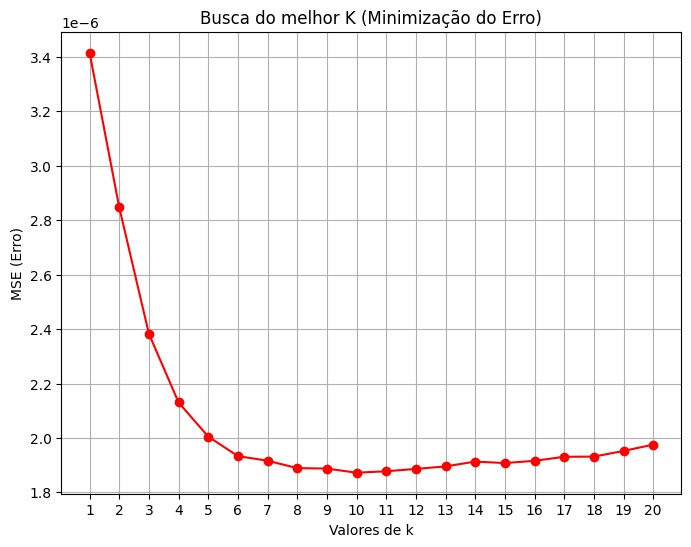

3.0896934116112196e-06
1.9755041856925407e-06


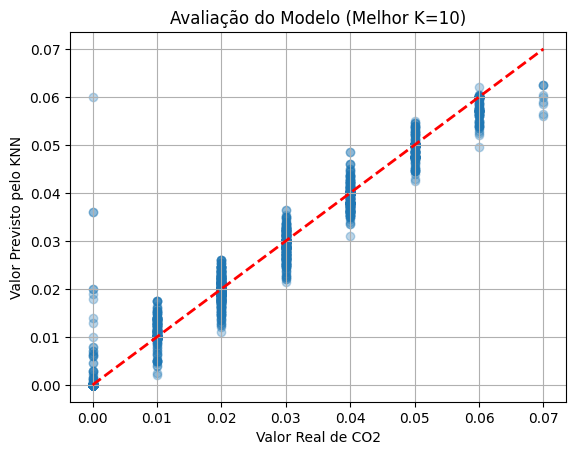

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [5]:
df  = pd.read_csv("/content/drive/MyDrive/5 semestre /Aprendizado de maquina supervisionado/IMD3002 - Aprendizado de Máquina Supervisionado/1-unidade/dataset/Steel_industry_data.csv")

print(df.columns.tolist())

features = [
    'Usage_kWh', 
    'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh',
    'Lagging_Current_Power_Factor',
    'Leading_Current_Power_Factor'
]

X = df[features]
Y = df[["CO2(tCO2)"]]

X_train, X_test, y_train, y_test = train_test_split(X,Y ,test_size=0.3,train_size=0.7, random_state=42)

print(f"X-train:{X_train.shape}, y-train:{y_train.shape}")
print(f"X-test:{X_test.shape}, y-test:{y_test.shape}")


scale = StandardScaler()


X_train_scarle = scale.fit_transform(X_train)
X_test_scarle = scale.transform(X_test)


# tem q char o melhor K antes de fazer o treinamento das coisas
k_values  = range(1,21)
mse_values = []
for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_scarle, y_train)
    y_pred_test = model.predict(X_test_scarle)
    
    mse_values.append(mean_squared_error(y_test, y_pred_test))



best_k = k_values[np.argmin(mse_values)]

print(f"\nMelhor valor de k é {best_k}, com MSE = {min(mse_values):.6f}.")

plt.figure(figsize=(8, 6))
plt.plot(k_values, mse_values, marker='o', color='red')
plt.xticks(k_values)
plt.xlabel('Valores de k')
plt.ylabel('MSE (Erro)')
plt.title('Busca do melhor K (Minimização do Erro)')
plt.grid()
plt.show()

model = KNeighborsRegressor(n_neighbors=best_k)
model.fit(X_train_scarle, y_train)
y_pred_train = model.predict(X_train_scarle)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test,y_pred_test)

print(mse_train)
print(mse_test)

plt.scatter(y_test, y_pred_test, color="tab:blue", alpha=0.3, label="Previsões")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel("Valor Real de CO2")
plt.ylabel("Valor Previsto pelo KNN")
plt.title(f"Avaliação do Modelo (Melhor K={best_k})")
plt.grid()
plt.show()



df.head()

## **Questão 2:**
<font size=3>

Resolva a tarefa de **classificação** do *dataset* [`load_wine`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) com o modelo [`KNeighborClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html). 

- Siga o **fluxo de trabalho** de aprendizado de máquina, aprendido no **_notebook_ 4**.
- **Encontre** o melhor valor de **k**.
  

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_wine

X-train:(124, 13), y-train:(124,)
X-test:(54, 13), y-test:(54,)

Melhor valor de k é 7, com acurácia = 0.98.


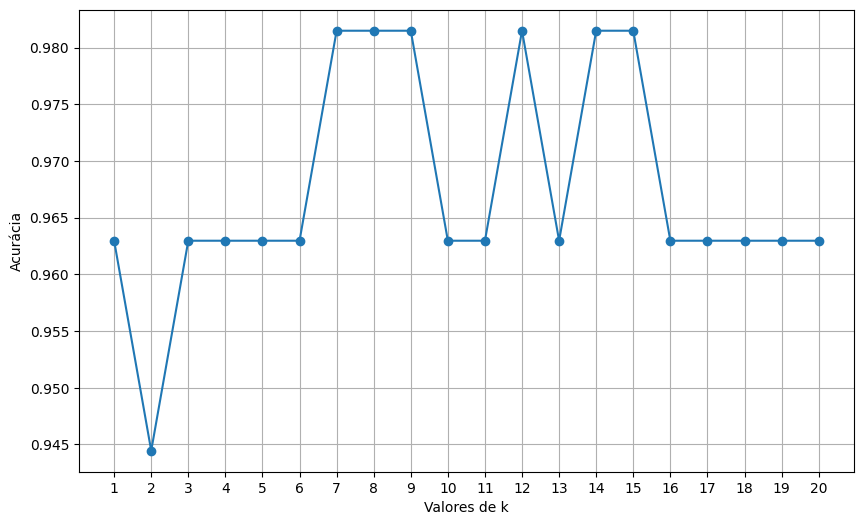

In [24]:
wine = load_wine()
X = wine.data
Y = wine.target


X_train, X_test, y_train, y_test = train_test_split(X,Y ,test_size=0.3,train_size=0.7, random_state=42)

print(f"X-train:{X_train.shape}, y-train:{y_train.shape}")
print(f"X-test:{X_test.shape}, y-test:{y_test.shape}")

scaler = StandardScaler()
X_train_scarle = scaler.fit_transform(X_train)
X_test_scarle = scaler.transform(X_test)

metric_values =[]
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scarle,y_train)
    y_pred= model.predict(X_test_scarle)
    metric_values.append(accuracy_score(y_test, y_pred))
best_k = k_values[np.argmax(metric_values)]

print(f"\nMelhor valor de k é {best_k}, com acurácia = {max(metric_values):.2f}.")

plt.figure(figsize=(10, 6))
plt.plot(k_values, metric_values, marker='o')
plt.xticks(k_values)
plt.xlabel('Valores de k')
plt.ylabel('Acurácia')
plt.grid()
plt.show()